In [1]:
import os
import sqlite3
from typing import Annotated, Literal, TypedDict
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file
from langchain_groq import ChatGroq
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_core.messages import AnyMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field

c:\python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
connection = sqlite3.connect("employee.db")

In [3]:
connection

In [4]:
table_creation_query="""
CREATE TABLE IF NOT EXISTS employees (
    emp_id INTEGER PRIMARY KEY,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    hire_date TEXT NOT NULL,
    salary REAL NOT NULL
);
"""

In [5]:
table_creation_query2="""
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY AUTOINCREMENT,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    phone TEXT
);
"""

In [6]:
table_creation_query3="""
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    amount REAL NOT NULL,
    FOREIGN KEY (customer_id) REFERENCES customers (customer_id)
);

"""

In [7]:
cursor=connection.cursor()

In [8]:
cursor.execute(table_creation_query)

In [9]:
cursor.execute(table_creation_query2)

In [10]:
cursor.execute(table_creation_query3)

In [11]:
insert_query = """
INSERT OR REPLACE INTO employees (emp_id, first_name, last_name, email, hire_date, salary)
VALUES (?, ?, ?, ?, ?, ?);
"""

In [12]:
insert_query_customers = """
INSERT OR REPLACE INTO customers (customer_id, first_name, last_name, email, phone)
VALUES (?, ?, ?, ?, ?);
"""

In [13]:
insert_query_orders = """
INSERT OR REPLACE INTO orders (order_id, customer_id, order_date, amount)
VALUES (?, ?, ?, ?);
"""


In [14]:
employee_data = [
    (1, "Sunny", "Savita", "sunny.sv@abc.com", "2023-06-01", 50000.00),
    (2, "Arhun", "Meheta", "arhun.m@gmail.com", "2022-04-15", 60000.00),
    (3, "Alice", "Johnson", "alice.johnson@jpg.com", "2021-09-30", 55000.00),
    (4, "Bob", "Brown", "bob.brown@uio.com", "2020-01-20", 45000.00),
    ]

In [15]:
customers_data = [
    (1, "John", "Doe", "john.doe@example.com", "1234567890"),
    (2, "Jane", "Smith", "jane.smith@example.com", "9876543210"),
    (3, "Emily", "Davis", "emily.davis@example.com", "4567891230"),
    (4, "Michael", "Brown", "michael.brown@example.com", "7894561230"),
]

In [16]:
orders_data = [
    (1, 1, "2023-12-01", 250.75),
    (2, 2, "2023-11-20", 150.50),
    (3, 3, "2023-11-25", 300.00),
    (4, 4, "2023-12-02", 450.00),
]

In [17]:
cursor.executemany(insert_query,employee_data)

In [18]:
cursor.executemany(insert_query_customers,customers_data)

In [19]:
cursor.executemany(insert_query_orders,orders_data)

In [20]:
connection.commit() # Save the changes to the database

In [21]:
cursor.execute("select * from orders;")

In [22]:
for row in cursor.fetchall():
    print(row)

(1, 1, '2023-12-01', 250.75)
(2, 2, '2023-11-20', 150.5)
(3, 3, '2023-11-25', 300.0)
(4, 4, '2023-12-02', 450.0)


In [23]:
cursor.execute("select first_name from employees where salary > 50000.0;")

In [24]:
cursor.fetchall()

[('Arhun',), ('Alice',)]

In [25]:
cursor.execute("SELECT name FROM sqlite_master WHERE type = 'table';")

In [26]:
cursor.fetchall()

[('employees',), ('customers',), ('sqlite_sequence',), ('orders',)]

In [27]:
import os
from dotenv import load_dotenv
load_dotenv()
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"]= GROQ_API_KEY
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"]= GOOGLE_API_KEY

In [28]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b")

# from langchain_google_genai import ChatGoogleGenerativeAI
# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

# from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(
#     # Point to the OpenAI-compatible "door"
#     base_url="http://localhost:11434/v1", 
    
#     # Required but ignored by Ollama
#     api_key="ollama", 
    
#     # The exact name you see in 'ollama list'
#     model="qwen2.5:1.5b", 
    
#     temperature=0
# )

In [29]:
llm.profile

{'max_input_tokens': 131072,
 'max_output_tokens': 16384,
 'image_inputs': False,
 'audio_inputs': False,
 'video_inputs': False,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': True,
 'tool_calling': True}

In [30]:
# llm.invoke("hello").content

In [31]:
from langchain_community.utilities import SQLDatabase
db = SQLDatabase.from_uri("sqlite:///employee.db")

In [32]:
print("Dialect:", db.dialect)
print("Usable tables:", db.get_usable_table_names())

Dialect: sqlite
Usable tables: ['customers', 'employees', 'orders']


In [33]:
query_result = db.run("SELECT * FROM employees ;")
print("Query result from Employees table: \n", query_result)

Query result from Employees table: 
 [(1, 'Sunny', 'Savita', 'sunny.sv@abc.com', '2023-06-01', 50000.0), (2, 'Arhun', 'Meheta', 'arhun.m@gmail.com', '2022-04-15', 60000.0), (3, 'Alice', 'Johnson', 'alice.johnson@jpg.com', '2021-09-30', 55000.0), (4, 'Bob', 'Brown', 'bob.brown@uio.com', '2020-01-20', 45000.0)]


In [34]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

In [35]:
toolkit=SQLDatabaseToolkit(db=db,llm=llm)

In [36]:
tools=toolkit.get_tools()

In [37]:
tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000012C6FB50EC0>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000012C6FB50EC0>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000012C6FB50EC0>),
 QuerySQLCheckerTool(description='Use this tool to 

In [38]:
for tool in tools:
    print(tool.name)

sql_db_query
sql_db_schema
sql_db_list_tables
sql_db_query_checker


In [39]:
list_tables_tool = next((tool for tool in tools if tool.name == "sql_db_list_tables"), None)

In [40]:
list_tables_tool

ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000012C6FB50EC0>)

In [41]:
get_schema_tool = next((tool for tool in tools if tool.name == "sql_db_schema"), None)

In [42]:
get_schema_tool

InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000012C6FB50EC0>)

In [43]:
print(list_tables_tool.invoke(""))

customers, employees, orders


In [44]:
print(get_schema_tool.invoke("employees"))


CREATE TABLE employees (
	emp_id INTEGER, 
	first_name TEXT NOT NULL, 
	last_name TEXT NOT NULL, 
	email TEXT NOT NULL, 
	hire_date TEXT NOT NULL, 
	salary REAL NOT NULL, 
	PRIMARY KEY (emp_id), 
	UNIQUE (email)
)

/*
3 rows from employees table:
emp_id	first_name	last_name	email	hire_date	salary
1	Sunny	Savita	sunny.sv@abc.com	2023-06-01	50000.0
2	Arhun	Meheta	arhun.m@gmail.com	2022-04-15	60000.0
3	Alice	Johnson	alice.johnson@jpg.com	2021-09-30	55000.0
*/


In [45]:
class SubmitFinalAnswer(BaseModel):
    """Submit the final natural language answer to the user."""
    final_answer: str = Field(..., description="The final answer to the user")

In [48]:
from langchain_core.tools import tool

In [49]:
@tool
def db_query_tool(query: str) -> str:
    """
    Execute a SQL query against the database and return the result.
    If the query is invalid, an error message is returned.
    """
    result = db.run_no_throw(query)
    if not result:
        return "Error: Query returned no results or failed. Check your logic."
    return result

In [50]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [51]:
def assistant(state: State):
    # Pro-tip: Providing table names in the system prompt saves 1 full API call!
    table_names = db.get_usable_table_names()
    
    system_prompt = f"""You are a SQL expert agent for a company database.
    Available Tables: {table_names}

    Steps:
    1. If you don't know the columns, use 'sql_db_schema'.
    2. Write and run a SQLite query using 'db_query_tool'.
    3. Analyze results and provide the 'SubmitFinalAnswer'.
    
    Rules:
    - Limit results to 5 unless specified.
    - If a query fails, look at the error and try a different query."""

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("placeholder", "{messages}")
    ])
    
    # Bind all tools so the model can choose any at any time
    agent_chain = prompt | llm.bind_tools([get_schema_tool, db_query_tool, SubmitFinalAnswer])
    return {"messages": [agent_chain.invoke(state)]}



In [52]:
# --- 4. BUILD THE GRAPH ---
workflow = StateGraph(State)

workflow.add_node("assistant", assistant)
workflow.add_node("tools", ToolNode([get_schema_tool, db_query_tool, SubmitFinalAnswer]))

workflow.add_edge(START, "assistant")
workflow.add_conditional_edges("assistant", tools_condition)
workflow.add_edge("tools", "assistant") # The loop back for analysis

app = workflow.compile()


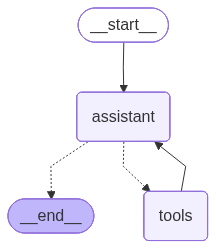

In [53]:
display(app)

In [54]:
query = {"messages": [("user", "Who is the employee with the highest salary?")]}

In [55]:
for event in app.stream(query):
    for value in event.values():
        last_msg = value["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            print(f"--- Agent calling tool: {last_msg.tool_calls[0]['name']} ---")
        elif isinstance(last_msg, ToolMessage):
            print(f"--- Tool Output received ---")
        else:
            print(f"Final Message: {last_msg.content}")

--- Agent calling tool: sql_db_schema ---
--- Tool Output received ---
--- Agent calling tool: db_query_tool ---
--- Tool Output received ---
--- Agent calling tool: SubmitFinalAnswer ---
--- Tool Output received ---
Final Message: The employee with the highest salary is **Arhun Meheta** with a salary of **$60,000**.


In [57]:
query={"messages": [("user", "Show the phone numbers of customers whose last name is 'Smith'?")]}

In [58]:
for event in app.stream(query):
    for value in event.values():
        last_msg = value["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            print(f"--- Agent calling tool: {last_msg.tool_calls[0]['name']} ---")
        elif isinstance(last_msg, ToolMessage):
            print(f"--- Tool Output received ---")
        else:
            print(f"Final Message: {last_msg.content}")

--- Agent calling tool: sql_db_schema ---
--- Tool Output received ---
--- Agent calling tool: db_query_tool ---
--- Tool Output received ---
--- Agent calling tool: SubmitFinalAnswer ---
--- Tool Output received ---
Final Message: The phone number of the customer with the last name 'Smith' is **9876543210**.
